# Static illustration of one GNN node update

This experiment illustrates one simplified manager-to-stock message-passing update. Neighboring manager representations are combined using normalized ownership-edge weights, joined with the stock's current representation, transformed linearly, and passed through a ReLU activation.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch


project_root = Path.cwd().resolve()

while not (project_root / 'config' / 'paths.yaml').is_file():
    if project_root.parent == project_root:
        raise FileNotFoundError('Could not locate the project root.')
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.utils.configuration import get_paths_config
from src.visualization.style import (
    COLOR_PALETTE,
    apply_matplotlib_layout,
    set_matplotlib_style,
)

set_matplotlib_style()
paths = get_paths_config()

In [2]:
manager_features = {
    'A': np.array([0.8, 0.2]),
    'B': np.array([0.3, 0.7]),
    'C': np.array([0.1, 0.4]),
}
ownership_weights = {'A': 0.50, 'B': 0.30, 'C': 0.20}
stock_features = np.array([0.4, 0.6])

neighbor_aggregate = sum(
    ownership_weights[manager] * features
    for manager, features in manager_features.items()
)
combined_features = np.concatenate([stock_features, neighbor_aggregate])
weight_matrix = np.array([
    [0.6, -0.4, 0.8, 0.2],
    [-0.8, 0.1, -0.3, 0.2],
])
pre_activation = weight_matrix @ combined_features
updated_embedding = np.maximum(pre_activation, 0.0)

print(f'Weighted neighbor aggregate: {neighbor_aggregate.round(3)}')
print(f'Before activation: {pre_activation.round(3)}')
print(f'Updated stock embedding: {updated_embedding.round(3)}')

Weighted neighbor aggregate: [0.51 0.39]
Before activation: [ 0.486 -0.335]
Updated stock embedding: [0.486 0.   ]


<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
C:\Users\salio\AppData\Local\Temp\ipykernel_16848\3064640482.py:17: SyntaxWarning: invalid escape sequence '\m'
  node_labels['Stock i'] = '$\mathbf{i}$'


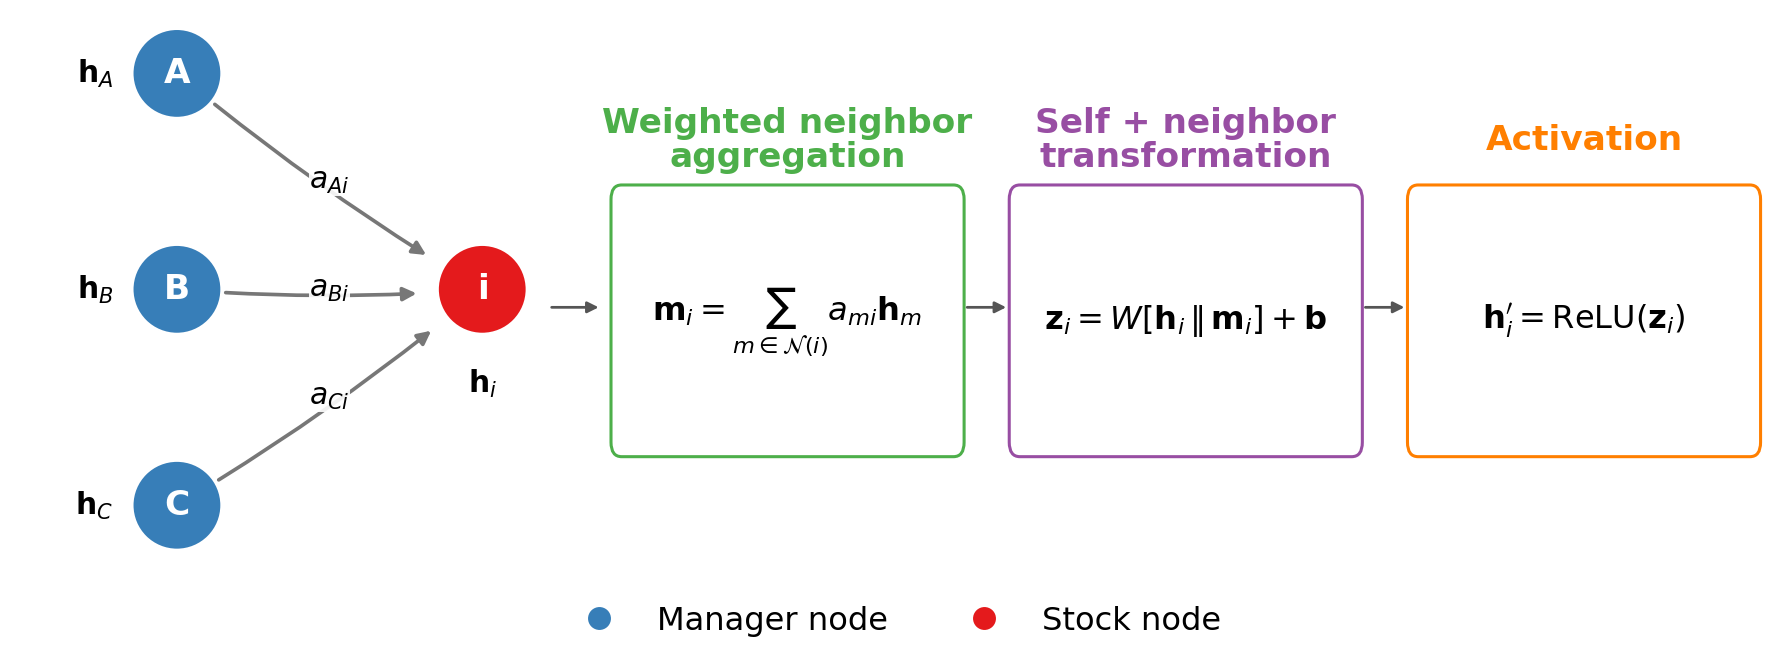

In [3]:
graph = nx.DiGraph()
graph.add_nodes_from(manager_features, node_type='manager')
graph.add_node('Stock i', node_type='stock')
graph.add_edges_from((manager, 'Stock i') for manager in manager_features)

positions = {
    'A': (1.5, 2.50),
    'B': (1.5, 1.30),
    'C': (1.5, 0.10),
    'Stock i': (3.8, 1.30),
}
edge_labels = {
    (manager, 'Stock i'): rf'$a_{{{manager}i}}$'
    for manager in ownership_weights
}
node_labels = {manager: manager for manager in manager_features}
node_labels['Stock i'] = '$\mathbf{i}$'

figure, axis = plt.subplots(figsize=(16.5, 6.2))
axis.grid(False)
axis.set_axis_off()

node_colors = [
    COLOR_PALETTE[0] if graph.nodes[node]['node_type'] == 'manager' else COLOR_PALETTE[1]
    for node in graph.nodes
]
node_sizes = [3400 for node in graph.nodes]

nx.draw_networkx_nodes(
    graph,
    positions,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors='white',
    linewidths=1.5,
    ax=axis,
)
nx.draw_networkx_labels(
    graph,
    positions,
    labels=node_labels,
    font_color='white',
    font_weight='bold',
    font_size=22.5,
    ax=axis,
)
nx.draw_networkx_edges(
    graph,
    positions,
    edge_color='#777777',
    width=2.4,
    arrows=True,
    arrowsize=18,
    min_source_margin=32,
    min_target_margin=43,
    connectionstyle='arc3,rad=0.04',
    ax=axis,
)
for manager, features in manager_features.items():
    axis.text(
        1.02,
        positions[manager][1],
        rf'$\mathbf{{h}}_{manager}$',
        ha='right',
        va='center',
        fontsize=19.5,
    )
axis.text(
    positions['Stock i'][0],
    0.78,
    r'$\mathbf{h}_i$',
    ha='center',
    va='center',
    fontsize=19.5,
)

nx.draw_networkx_edge_labels(
    graph,
    positions,
    edge_labels=edge_labels,
    rotate=False,
    font_size=19.5,
    label_pos=0.50,
    bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.90, 'pad': 0.2},
    ax=axis,
)

def add_step_box(x, title, text, color):
    box = FancyBboxPatch(
        (x, 0.45),
        2.50,
        1.35,
        boxstyle='round,pad=0.08',
        facecolor='white',
        edgecolor=color,
        linewidth=2.0,
    )
    axis.add_patch(box)
    axis.text(
        x + 1.25,
        2.13,
        title,
        ha='center',
        va='center',
        fontsize=22.5,
        fontweight='bold',
        color=color,
        linespacing=1.05,
    )
    axis.text(
        x + 1.25,
        1.125,
        text,
        ha='center',
        va='center',
        fontsize=21,
        linespacing=1.25,
    )

aggregate_text = r'$\mathbf{m}_i=\sum_{m\in\mathcal{N}(i)}a_{mi}\mathbf{h}_m$'
linear_text = r'$\mathbf{z}_i=W[\mathbf{h}_i\,\Vert\,\mathbf{m}_i]+\mathbf{b}$'
activation_text = r'$\mathbf{h}_i^{\prime}=\operatorname{ReLU}(\mathbf{z}_i)$'

add_step_box(4.85, 'Weighted neighbor\naggregation', aggregate_text, COLOR_PALETTE[2])
add_step_box(7.85, 'Self + neighbor\ntransformation', linear_text, COLOR_PALETTE[3])
add_step_box(10.85, 'Activation', activation_text, COLOR_PALETTE[4])

for start, end in [(4.30, 4.70), (7.43, 7.77), (10.43, 10.77)]:
    axis.annotate(
        '',
        xy=(end, 1.20),
        xytext=(start, 1.20),
        arrowprops={'arrowstyle': '-|>', 'color': '#555555', 'lw': 1.8},
    )

legend_handles = [
    Line2D([0], [0], marker='o', linestyle='none', markerfacecolor=COLOR_PALETTE[0], markeredgecolor='none', markersize=15, label='Manager node'),
    Line2D([0], [0], marker='o', linestyle='none', markerfacecolor=COLOR_PALETTE[1], markeredgecolor='none', markersize=15, label='Stock node'),
]
axis.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.50, -0.07), ncol=2, fontsize=21)
axis.set_xlim(0.25, 13.55)
axis.set_ylim(-0.55, 2.85)
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / '08_05_gnn_node_update.pdf')
plt.show()

## Interpretation

The illustration separates the four elements of weighted GraphSAGE message passing: neighboring node representations, edge-weighted aggregation, a learned linear transformation, and a nonlinear activation. It is conceptual rather than an exact rendering of every architecture used in the thesis; GraphSAGE and GAT differ principally in how neighbor messages and their weights are constructed.